In [3]:
!pip install timm kaggle seaborn -q

In [4]:
from google.colab import files
files.upload()  # kaggle.json yükle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d iarunava/cell-images-for-detecting-malaria
!unzip -q cell-images-for-detecting-malaria.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
License(s): unknown
100% 675M/675M [00:06<00:00, 104MB/s] 



In [5]:
import os, time
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import timm

In [6]:
for root, dirs, files in os.walk("cell_images"):
    for f in files:
        if not f.lower().endswith((".png", ".jpg", ".jpeg")):
            os.remove(os.path.join(root, f))

print("Temizleme tamam")

Temizleme tamam


In [7]:
parasitized_dir = "cell_images/Parasitized"
uninfected_dir = "cell_images/Uninfected"

def is_img(f):
    return f.lower().endswith((".png", ".jpg", ".jpeg"))

data = []
labels = []

for f in os.listdir(parasitized_dir):
    if is_img(f):
        data.append(os.path.join(parasitized_dir, f))
        labels.append(1)

for f in os.listdir(uninfected_dir):
    if is_img(f):
        data.append(os.path.join(uninfected_dir, f))
        labels.append(0)

print("Toplam veri:", len(data))

Toplam veri: 27558


In [8]:
train_paths, test_paths, train_labels, test_labels = train_test_split(
    data, labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

In [9]:
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [10]:
class MalariaDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
            img = self.transform(img)
            label = self.labels[idx]
            return img, label
        except:
            return self.__getitem__((idx+1) % len(self.paths))

In [11]:
train_ds = MalariaDataset(train_paths, train_labels, train_tf)
test_ds = MalariaDataset(test_paths, test_labels, test_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model("vit_tiny_patch16_224", pretrained=True)


model.head = nn.Linear(model.head.in_features, 1)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

In [13]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [14]:
epochs = 10

train_losses = []
train_accs = []

val_losses = []
val_accs = []

start_time = time.time()

for epoch in range(epochs):


    model.train()
    train_loss_sum = 0
    train_correct = 0
    train_total = 0

    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(imgs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()

        preds = (torch.sigmoid(outputs) > 0.5).int()
        train_correct += (preds == labels.int()).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_sum / len(train_loader)
    train_acc = train_correct / train_total

    train_losses.append(train_loss)
    train_accs.append(train_acc)


    model.eval()
    val_loss_sum = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item()

            preds = (torch.sigmoid(outputs) > 0.5).int()
            val_correct += (preds == labels.int()).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / len(test_loader)
    val_acc = val_correct / val_total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

end_time = time.time()
training_time = end_time - start_time

print("Total training time:", training_time)

Epoch [1/10] Train Loss: 0.1304 Acc: 0.9561 | Val Loss: 0.1261 Acc: 0.9606
Epoch [2/10] Train Loss: 0.0959 Acc: 0.9655 | Val Loss: 0.0867 Acc: 0.9690
Epoch [3/10] Train Loss: 0.0832 Acc: 0.9714 | Val Loss: 0.0745 Acc: 0.9744
Epoch [4/10] Train Loss: 0.0768 Acc: 0.9727 | Val Loss: 0.0923 Acc: 0.9652
Epoch [5/10] Train Loss: 0.0675 Acc: 0.9754 | Val Loss: 0.0830 Acc: 0.9692
Epoch [6/10] Train Loss: 0.0606 Acc: 0.9793 | Val Loss: 0.0743 Acc: 0.9755
Epoch [7/10] Train Loss: 0.0559 Acc: 0.9810 | Val Loss: 0.1024 Acc: 0.9641
Epoch [8/10] Train Loss: 0.0533 Acc: 0.9819 | Val Loss: 0.0815 Acc: 0.9741
Epoch [9/10] Train Loss: 0.0465 Acc: 0.9839 | Val Loss: 0.0822 Acc: 0.9761
Epoch [10/10] Train Loss: 0.0413 Acc: 0.9849 | Val Loss: 0.1059 Acc: 0.9701
Total training time: 1520.5501568317413


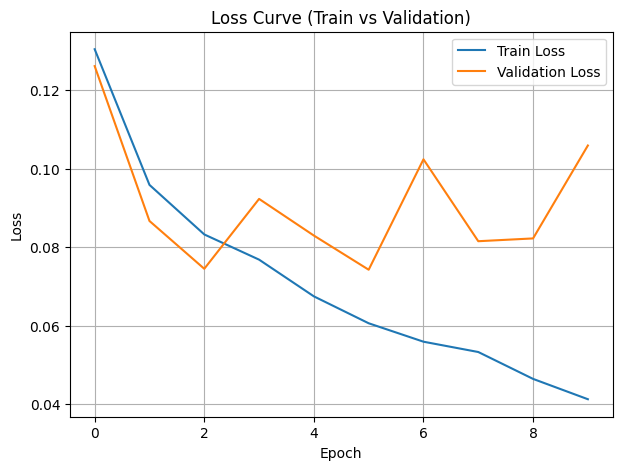

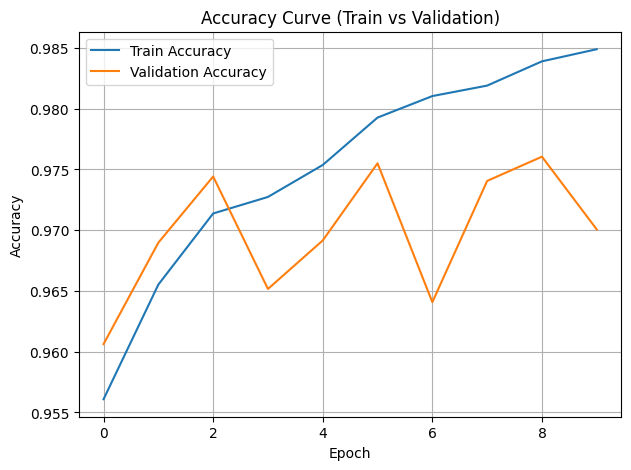

In [15]:
plt.figure(figsize=(7,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Loss Curve (Train vs Validation)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(7,5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.title("Accuracy Curve (Train vs Validation)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()


In [17]:
all_true = []
all_preds = []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        outputs = model(imgs)
        preds = (torch.sigmoid(outputs) > 0.5).int()

        all_true.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

acc = accuracy_score(all_true, all_preds)
prec = precision_score(all_true, all_preds, average='macro')
rec = recall_score(all_true, all_preds, average='macro')
f1 = f1_score(all_true, all_preds, average='macro')

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-score :", f1)

Accuracy : 0.9700653120464441
Precision: 0.9701411359108154
Recall   : 0.9700653120464441
F1-score : 0.9700641050390872


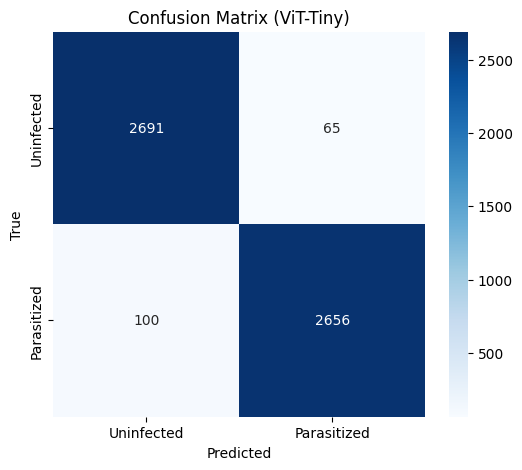

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Uninfected", "Parasitized"],
    yticklabels=["Uninfected", "Parasitized"]
)

plt.title("Confusion Matrix (ViT-Tiny)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()